# v5 — Expanding moments, agnostic yellow / red

v4 scored a **finished** 500-sample run. Here the unit is still a run (500 samples), but the statistics **update every sample**:

- sample 1 → mean / sd / skew / kurtosis of `{1}`
- samples 1–2 → moments of `{1,2}`
- samples 1–t → moments of `{1,…,t}`

An alarm is a **critical change in those four expanding moments**, not a label. The detector never reads `faultNumber`, `fault_status`, or train/test. Each run calibrates its own noise from the first 20 samples (the in-control head of a TE simulation), then scores later samples against that baseline.

**Yellow** = unusual moment jump. **Red** = extreme jump (red replaces yellow on that sample). A quiet run has **zero** alarms and is just the moment curves.

**Corpus.** `te_process.csv` is ~15.3M rows, but unique runs are **21,000** (21 IDVs × 500 sims × {train, test}), not 15.3M/500. Test files are 960 samples long; we keep **samples 1–500** so every run has the same window. This notebook draws **20 random runs** (seed 42). The same functions apply to all 21,000 later.


In [2]:
from __future__ import annotations

import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

log = logging.getLogger("v5_stat")
if not log.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s  %(levelname)-7s  %(message)s", datefmt="%H:%M:%S"))
    log.addHandler(handler)
    log.setLevel(logging.INFO)
    log.propagate = False

CSV_PATH = Path("te_process.csv")
CATALOG_PATH = Path("run_moments_s1_500.csv")
SAMPLE_CACHE = Path("v5_sample20_runs.csv")
CHUNKSIZE = 250_000
META_COLS = ["faultNumber", "simulationRun", "sample", "source", "fault_status"]
SAMPLE_MAX = 500
N_RUNS = 20
SPLIT_SEED = 42
PLOT_SENSOR = "xmeas_7"  # reactor pressure
PLOT_SENSORS = [f"xmeas_{i}" for i in (1, 7, 9, 13, 18, 21)]

# Detector: first BURNIN samples are the per-run null. No labels.
MIN_T = 8
BURNIN = 20
YELLOW_Z = 3.5
RED_Z = 6.0
SENSOR_Q = 0.90  # robust to 1-2 wild channels; needs several sensors to move

YELLOW = "#E0B000"
RED = "#C0392B"

log.info("csv         %s", CSV_PATH.resolve())
log.info("exists      %s", CSV_PATH.exists())
log.info("window      samples 1–%s", SAMPLE_MAX)
log.info("this pass   %s random runs  seed=%s", N_RUNS, SPLIT_SEED)
log.info("burn-in     samples %s–%s  (self-calibrate, no labels)", MIN_T, BURNIN)
log.info("thresholds  yellow z≥%s (2 consecutive)  red z≥%s (immediate)", YELLOW_Z, RED_Z)


## 1. Draw 20 runs and stream their rows

Pick 20 keys uniformly from the 21,000-run catalog, then stream the CSV once and keep only those trajectories (`sample <= 500`). Cached to `v5_sample20_runs.csv` so re-runs skip the 15M-row scan.


In [4]:
def sensor_columns(columns) -> list[str]:
    return [c for c in columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]


def compact_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "faultNumber" in out.columns:
        out["faultNumber"] = out["faultNumber"].astype(np.int16)
    if "simulationRun" in out.columns:
        out["simulationRun"] = out["simulationRun"].astype(np.int16)
    if "sample" in out.columns:
        out["sample"] = out["sample"].astype(np.int16)
    if "source" in out.columns:
        out["source"] = out["source"].astype(str)
    if "fault_status" in out.columns:
        out["fault_status"] = out["fault_status"].astype(str)
    return out


def load_run_catalog() -> pd.DataFrame:
    if CATALOG_PATH.exists():
        cat = pd.read_csv(CATALOG_PATH, usecols=["source", "faultNumber", "simulationRun"])
        log.info("catalog     %s  runs=%s", CATALOG_PATH.name, f"{len(cat):,}")
        return compact_frame(cat)
    keys = []
    header = pd.read_csv(CSV_PATH, nrows=0)
    usecols = [c for c in META_COLS if c in header.columns]
    for chunk in pd.read_csv(CSV_PATH, usecols=usecols, chunksize=CHUNKSIZE):
        live = compact_frame(chunk.loc[chunk["sample"].astype(int).le(SAMPLE_MAX)])
        keys.append(live[["source", "faultNumber", "simulationRun"]].drop_duplicates())
    cat = pd.concat(keys, ignore_index=True).drop_duplicates()
    log.info("catalog     streamed  runs=%s", f"{len(cat):,}")
    return cat


def draw_run_keys(n: int = N_RUNS, seed: int = SPLIT_SEED) -> pd.DataFrame:
    cat = load_run_catalog()
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(cat), size=min(n, len(cat)), replace=False)
    picked = cat.iloc[idx].copy().reset_index(drop=True)
    return picked.sort_values(["source", "faultNumber", "simulationRun"]).reset_index(drop=True)


def stream_selected_runs(keys: pd.DataFrame) -> pd.DataFrame:
    keyset = set(
        zip(keys["source"].astype(str), keys["faultNumber"].astype(int), keys["simulationRun"].astype(int))
    )
    header = pd.read_csv(CSV_PATH, nrows=0)
    sensors = sensor_columns(header.columns)
    usecols = [c for c in META_COLS + sensors if c in header.columns]
    parts: list[pd.DataFrame] = []
    have: set[tuple] = set()
    t0 = time.time()
    for i, chunk in enumerate(pd.read_csv(CSV_PATH, usecols=usecols, chunksize=CHUNKSIZE), start=1):
        live = compact_frame(chunk.loc[chunk["sample"].astype(int).le(SAMPLE_MAX)])
        mask = [
            (s, int(f), int(r)) in keyset
            for s, f, r in zip(live["source"], live["faultNumber"], live["simulationRun"])
        ]
        sub = live.loc[mask]
        if len(sub):
            parts.append(sub)
            have |= set(zip(sub["source"].astype(str), sub["faultNumber"].astype(int), sub["simulationRun"].astype(int)))
        if i % 10 == 0:
            log.info("stream      chunk %s  keys=%s/%s  %.1fs", i, len(have), len(keyset), time.time() - t0)
        if have >= keyset:
            log.info("stream      all keys complete at chunk %s  %.1fs", i, time.time() - t0)
            break
    out = pd.concat(parts, ignore_index=True)
    return out.sort_values(["source", "faultNumber", "simulationRun", "sample"]).reset_index(drop=True)


def load_sample_runs() -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    keys = draw_run_keys()
    if SAMPLE_CACHE.exists():
        raw = compact_frame(pd.read_csv(SAMPLE_CACHE))
        raw = raw.loc[raw["sample"].astype(int).le(SAMPLE_MAX)]
        got = (
            raw[["source", "faultNumber", "simulationRun"]]
            .drop_duplicates()
            .sort_values(["source", "faultNumber", "simulationRun"])
            .reset_index(drop=True)
        )
        want = keys.sort_values(["source", "faultNumber", "simulationRun"]).reset_index(drop=True)
        if got.equals(want) and got.shape[0] == N_RUNS:
            log.info("cache hit   %s  rows=%s", SAMPLE_CACHE.name, f"{len(raw):,}")
            sensors = sensor_columns(raw.columns)
            return keys, raw, sensors
        log.info("cache miss  keys changed — restreaming")
    raw = stream_selected_runs(keys)
    raw.to_csv(SAMPLE_CACHE, index=False)
    log.info("cache write %s  rows=%s", SAMPLE_CACHE.name, f"{len(raw):,}")
    return keys, raw, sensor_columns(raw.columns)


keys, runs, SENSOR_COLS = load_sample_runs()
plot_sensor = PLOT_SENSOR if PLOT_SENSOR in SENSOR_COLS else SENSOR_COLS[0]
log.info("sensors     %s", len(SENSOR_COLS))
log.info("plot sensor %s", plot_sensor)
print("20 random runs (labels are display-only; detector does not use them)")
keys_show = keys.assign(faultNumber=keys["faultNumber"].astype(int), simulationRun=keys["simulationRun"].astype(int))
print(keys_show.to_string(index=False))
display(keys_show)


20 random runs (labels are display-only; detector does not use them)
source  faultNumber  simulationRun
  test            3            304
  test            3            373
  test            3            477
  test            5            191
  test            8            229
  test           18             87
  test           18            210
  test           18            459
 train            0            277
 train            1             52
 train            6            235
 train            8            137
 train            9             64
 train            9            446
 train           10            480
 train           11            240
 train           12              5
 train           14            134
 train           15             19
 train           19            481


,source,faultNumber,simulationRun
0,test,3,304
1,test,3,373
2,test,3,477
3,test,5,191
4,test,8,229
5,test,18,87
6,test,18,210
7,test,18,459
8,train,0,277
9,train,1,52


## 2. Expanding mean, sd, skew, kurtosis

For a run matrix `X` of shape `(T, n_sensors)`, at row `t` the four numbers are pandas `mean / std / skew / kurt` of samples `1…t` (excess kurtosis, bias-corrected). Sample 1 has only a mean; sd starts at 2, skew at 3, kurtosis at 4.


In [6]:
def expanding_moments(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Moments of samples 1..t for every t. Matches pandas expanding()."""
    ex = pd.DataFrame(np.asarray(X, dtype=np.float64)).expanding(min_periods=1)
    return (
        ex.mean().to_numpy(np.float64),
        ex.std(ddof=1).to_numpy(np.float64),
        ex.skew().to_numpy(np.float64),
        ex.kurt().to_numpy(np.float64),
    )


# Check against a full-window pandas row on one sensor of the first run.
_probe = next(iter(runs.groupby(["source", "faultNumber", "simulationRun"], sort=True)))[1]
_x = _probe.sort_values("sample")[plot_sensor].to_numpy(np.float64)
_mean, _sd, _skew, _kurt = expanding_moments(_x[:, None])
_s = pd.Series(_x)
assert np.isclose(_mean[-1, 0], _s.mean())
assert np.isclose(_sd[-1, 0], _s.std(ddof=1))
assert np.isclose(_skew[-1, 0], _s.skew())
assert np.isclose(_kurt[-1, 0], _s.kurt())
log.info("expanding   pandas match on %s  n=%s", plot_sensor, len(_x))


## 3. Agnostic yellow / red

Adding sample `t` is the only thing that can move the expanding moments. Under a stationary sensor the new value, studentized against **yesterday's** expanding mean and sd,

$$z_t = (x_t - \mu_{t-1}) / \sigma_{t-1}$$

has (approximately) mean 0 and variance 1. The four moment surprises are the usual Gaussian influence functions:

| moment | surprise |
| --- | --- |
| mean | $\|z\|$ |
| sd | $\|z^2 - 1\| / \sqrt{2}$ |
| skew | $\|z^3\| / \sqrt{15}$ |
| kurtosis | $\|z^4 - 3\| / \sqrt{96}$ |

Per sensor we take the RMS of those four. Per sample we take the **90th percentile across sensors** so one noisy channel cannot raise the plant, but a disturbance that moves several channels can.

That scalar `S_t` is then turned into a **run-specific** z-score using the median and MAD of `S_t` on samples 8–20 (after moments exist, before a TE train fault at sample 21). Thresholds are therefore scale-free: they do not depend on IDV, units, or other runs.

- **red** if $z(S_t) \ge 6$ (one sample is enough)
- **yellow** if $z(S_t) \ge 3.5$ on **two consecutive** samples and the sample is not already red
- otherwise no alarm

A run may have 0, 1, or many alarms. Consecutive hits are kept as a burst (typical around a real distribution shift).


In [8]:
MOMENT_NAMES = np.array(["mean", "sd", "skew", "kurt"])


def moment_surprises(X: np.ndarray, mean: np.ndarray, sd: np.ndarray) -> dict[str, np.ndarray]:
    T, n_s = X.shape
    z = np.full((T, n_s), np.nan)
    floor = np.maximum(1e-6 * np.abs(mean[:-1]), 1e-8)
    past_sd = np.maximum(sd[:-1], floor)
    with np.errstate(invalid="ignore", over="ignore", divide="ignore"):
        z[1:] = np.clip((X[1:] - mean[:-1]) / past_sd, -20.0, 20.0)
        return {
            "mean": np.abs(z),
            "sd": np.abs(z**2 - 1.0) / np.sqrt(2.0),
            "skew": np.abs(z**3) / np.sqrt(15.0),
            "kurt": np.abs(z**4 - 3.0) / np.sqrt(96.0),
        }


def combined_score(surprises: dict[str, np.ndarray]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    stack = np.stack([surprises[k] for k in MOMENT_NAMES], axis=0)  # (4, T, S)
    with np.errstate(invalid="ignore", divide="ignore"):
        sensor_score = np.sqrt(np.nanmean(np.where(np.isfinite(stack), stack**2, np.nan), axis=0))
    T = sensor_score.shape[0]
    score = np.full(T, np.nan)
    ok = np.isfinite(sensor_score).any(axis=1)
    if ok.any():
        score[ok] = np.nanquantile(sensor_score[ok], SENSOR_Q, axis=1)
    q4 = np.full((4, T), np.nan)
    if ok.any():
        q4[:, ok] = np.nanquantile(stack[:, ok, :], SENSOR_Q, axis=2)
    q4_fill = np.where(np.isfinite(q4), q4, -np.inf)
    mom_id = np.argmax(q4_fill, axis=0).astype(np.int8)
    return score, mom_id, sensor_score


def calibrate(score: np.ndarray) -> tuple[float, float]:
    cal = score[MIN_T - 1 : BURNIN]
    mu = float(np.nanmedian(cal))
    sig = float(1.4826 * np.nanmedian(np.abs(cal - mu)))
    if not np.isfinite(mu):
        mu = 0.0
    if not np.isfinite(sig) or sig < 0.25:
        sig = 0.25
    return mu, sig


def detect_alarms(score: np.ndarray, mu: float, sig: float) -> tuple[np.ndarray, np.ndarray]:
    """Return (z, level) with level 0 / 1 yellow / 2 red. Causal. No labels."""
    T = len(score)
    z = (score - mu) / sig
    z[:BURNIN] = np.nan
    raw = np.zeros(T, dtype=np.int8)
    finite = np.isfinite(z)
    raw[finite & (z >= YELLOW_Z)] = 1
    raw[finite & (z >= RED_Z)] = 2
    level = np.zeros(T, dtype=np.int8)
    for t in range(BURNIN, T):
        if raw[t] == 2:
            level[t] = 2
        elif raw[t] == 1 and raw[t - 1] >= 1:
            level[t] = 1
    return z, level


def alarm_spans(level: np.ndarray, samples: np.ndarray) -> list[tuple[float, float, str]]:
    """Inclusive sample ranges of consecutive yellow or red."""
    spans = []
    t = 0
    T = len(level)
    while t < T:
        if level[t] == 0:
            t += 1
            continue
        val = int(level[t])
        t0 = t
        while t < T and level[t] == val:
            t += 1
        color = RED if val == 2 else YELLOW
        spans.append((float(samples[t0]), float(samples[t - 1]), color))
    return spans


def n_events(level: np.ndarray, val: int) -> int:
    prev = np.concatenate([[0], level[:-1]])
    return int(np.sum((level == val) & (prev != val)))


def first_sample(mask: np.ndarray, samples: np.ndarray) -> int | None:
    idx = np.flatnonzero(mask)
    return int(samples[idx[0]]) if len(idx) else None


def analyze_run(frame: pd.DataFrame) -> dict:
    frame = frame.sort_values("sample")
    samples = frame["sample"].to_numpy(np.int16)
    X = frame[SENSOR_COLS].to_numpy(np.float64)
    mean, sd, skew, kurt = expanding_moments(X)
    surprises = moment_surprises(X, mean, sd)
    score, mom_id, sensor_score = combined_score(surprises)
    mu, sig = calibrate(score)
    z, level = detect_alarms(score, mu, sig)
    alarm = level > 0
    if alarm.any():
        mom_counts = pd.Series(MOMENT_NAMES[mom_id[alarm]]).value_counts().to_dict()
    else:
        mom_counts = {}
    return {
        "source": str(frame["source"].iloc[0]),
        "faultNumber": int(frame["faultNumber"].iloc[0]),
        "simulationRun": int(frame["simulationRun"].iloc[0]),
        "fault_status": str(frame["fault_status"].iloc[0]),
        "samples": samples,
        "X": X,
        "mean": mean,
        "sd": sd,
        "skew": skew,
        "kurt": kurt,
        "score": score,
        "z": z,
        "level": level,
        "mu": mu,
        "sig": sig,
        "mom_id": mom_id,
        "mom_counts": mom_counts,
        "sensor_score": sensor_score,
        "spans": alarm_spans(level, samples),
    }


analyzed = []
for _, g in runs.groupby(["source", "faultNumber", "simulationRun"], sort=True):
    analyzed.append(analyze_run(g))

summary = pd.DataFrame(
    {
        "source": [a["source"] for a in analyzed],
        "IDV": [a["faultNumber"] for a in analyzed],
        "run": [a["simulationRun"] for a in analyzed],
        "csv_status": [a["fault_status"] for a in analyzed],  # not an input to the detector
        "n_yellow": [(a["level"] == 1).sum() for a in analyzed],
        "n_red": [(a["level"] == 2).sum() for a in analyzed],
        "events_yellow": [n_events(a["level"], 1) for a in analyzed],
        "events_red": [n_events(a["level"], 2) for a in analyzed],
        "first_yellow": [first_sample(a["level"] == 1, a["samples"]) for a in analyzed],
        "first_red": [first_sample(a["level"] == 2, a["samples"]) for a in analyzed],
        "z_max": [round(float(np.nanmax(a["z"][BURNIN:])), 2) if np.isfinite(a["z"][BURNIN:]).any() else np.nan for a in analyzed],
        "top_moment": [
            (max(a["mom_counts"], key=a["mom_counts"].get) if a["mom_counts"] else "") for a in analyzed
        ],
    }
)
log.info("runs scored %s", len(analyzed))
log.info("any alarm  %s / %s", int(((summary.n_yellow + summary.n_red) > 0).sum()), len(summary))
log.info("yellow smp %s   red smp %s", int(summary.n_yellow.sum()), int(summary.n_red.sum()))
print("Alarms are sample counts (a burst around a shift is many samples, few events). csv_status is not used for decisions.")
print(summary.to_string(index=False))
display(summary)


Alarms are sample counts (a burst around a shift is many samples, few events). csv_status is not used for decisions.
source  IDV  run csv_status  n_yellow  n_red  events_yellow  events_red  first_yellow  first_red  z_max top_moment
  test    3  304     faulty         0      0              0           0           NaN        NaN   2.84           
  test    3  373     faulty         0      0              0           0           NaN        NaN   1.35           
  test    3  477     faulty         0      0              0           0           NaN        NaN   3.65           
  test    5  191     faulty         8     18              6           2         174.0      177.0  12.09       kurt
  test    8  229     faulty        14     16              6           3         206.0      209.0  12.27       kurt
  test   18   87     faulty        15    142             10           9         196.0      245.0 434.04       kurt
  test   18  210     faulty        19     79             10           7       

,source,IDV,run,csv_status,n_yellow,n_red,events_yellow,events_red,first_yellow,first_red,z_max,top_moment
0,test,3,304,faulty,0,0,0,0,NaN,NaN,2.84,
1,test,3,373,faulty,0,0,0,0,NaN,NaN,1.35,
2,test,3,477,faulty,0,0,0,0,NaN,NaN,3.65,
3,test,5,191,faulty,8,18,6,2,174.0,177.0,12.09,kurt
4,test,8,229,faulty,14,16,6,3,206.0,209.0,12.27,kurt
5,test,18,87,faulty,15,142,10,9,196.0,245.0,434.04,kurt
6,test,18,210,faulty,19,79,10,7,194.0,271.0,96.27,kurt
7,test,18,459,faulty,34,72,9,6,220.0,199.0,261.89,kurt
8,train,0,277,normal,0,0,0,0,NaN,NaN,4.02,
9,train,1,52,faulty,8,8,4,2,28.0,25.0,19.53,kurt


## 4. Plots

Each panel is one run. The score plot is the **run-specific z** of the combined 4-moment surprise, with dashed yellow (3.5) and red (6) lines. Shaded bands are the alarms; a quiet run has no band.

The second figure is the expanding **mean, sd, skew, kurtosis** of `xmeas_7` (reactor pressure) with the same bands. The detector uses all 52 channels; this sensor is only for reading the curves.


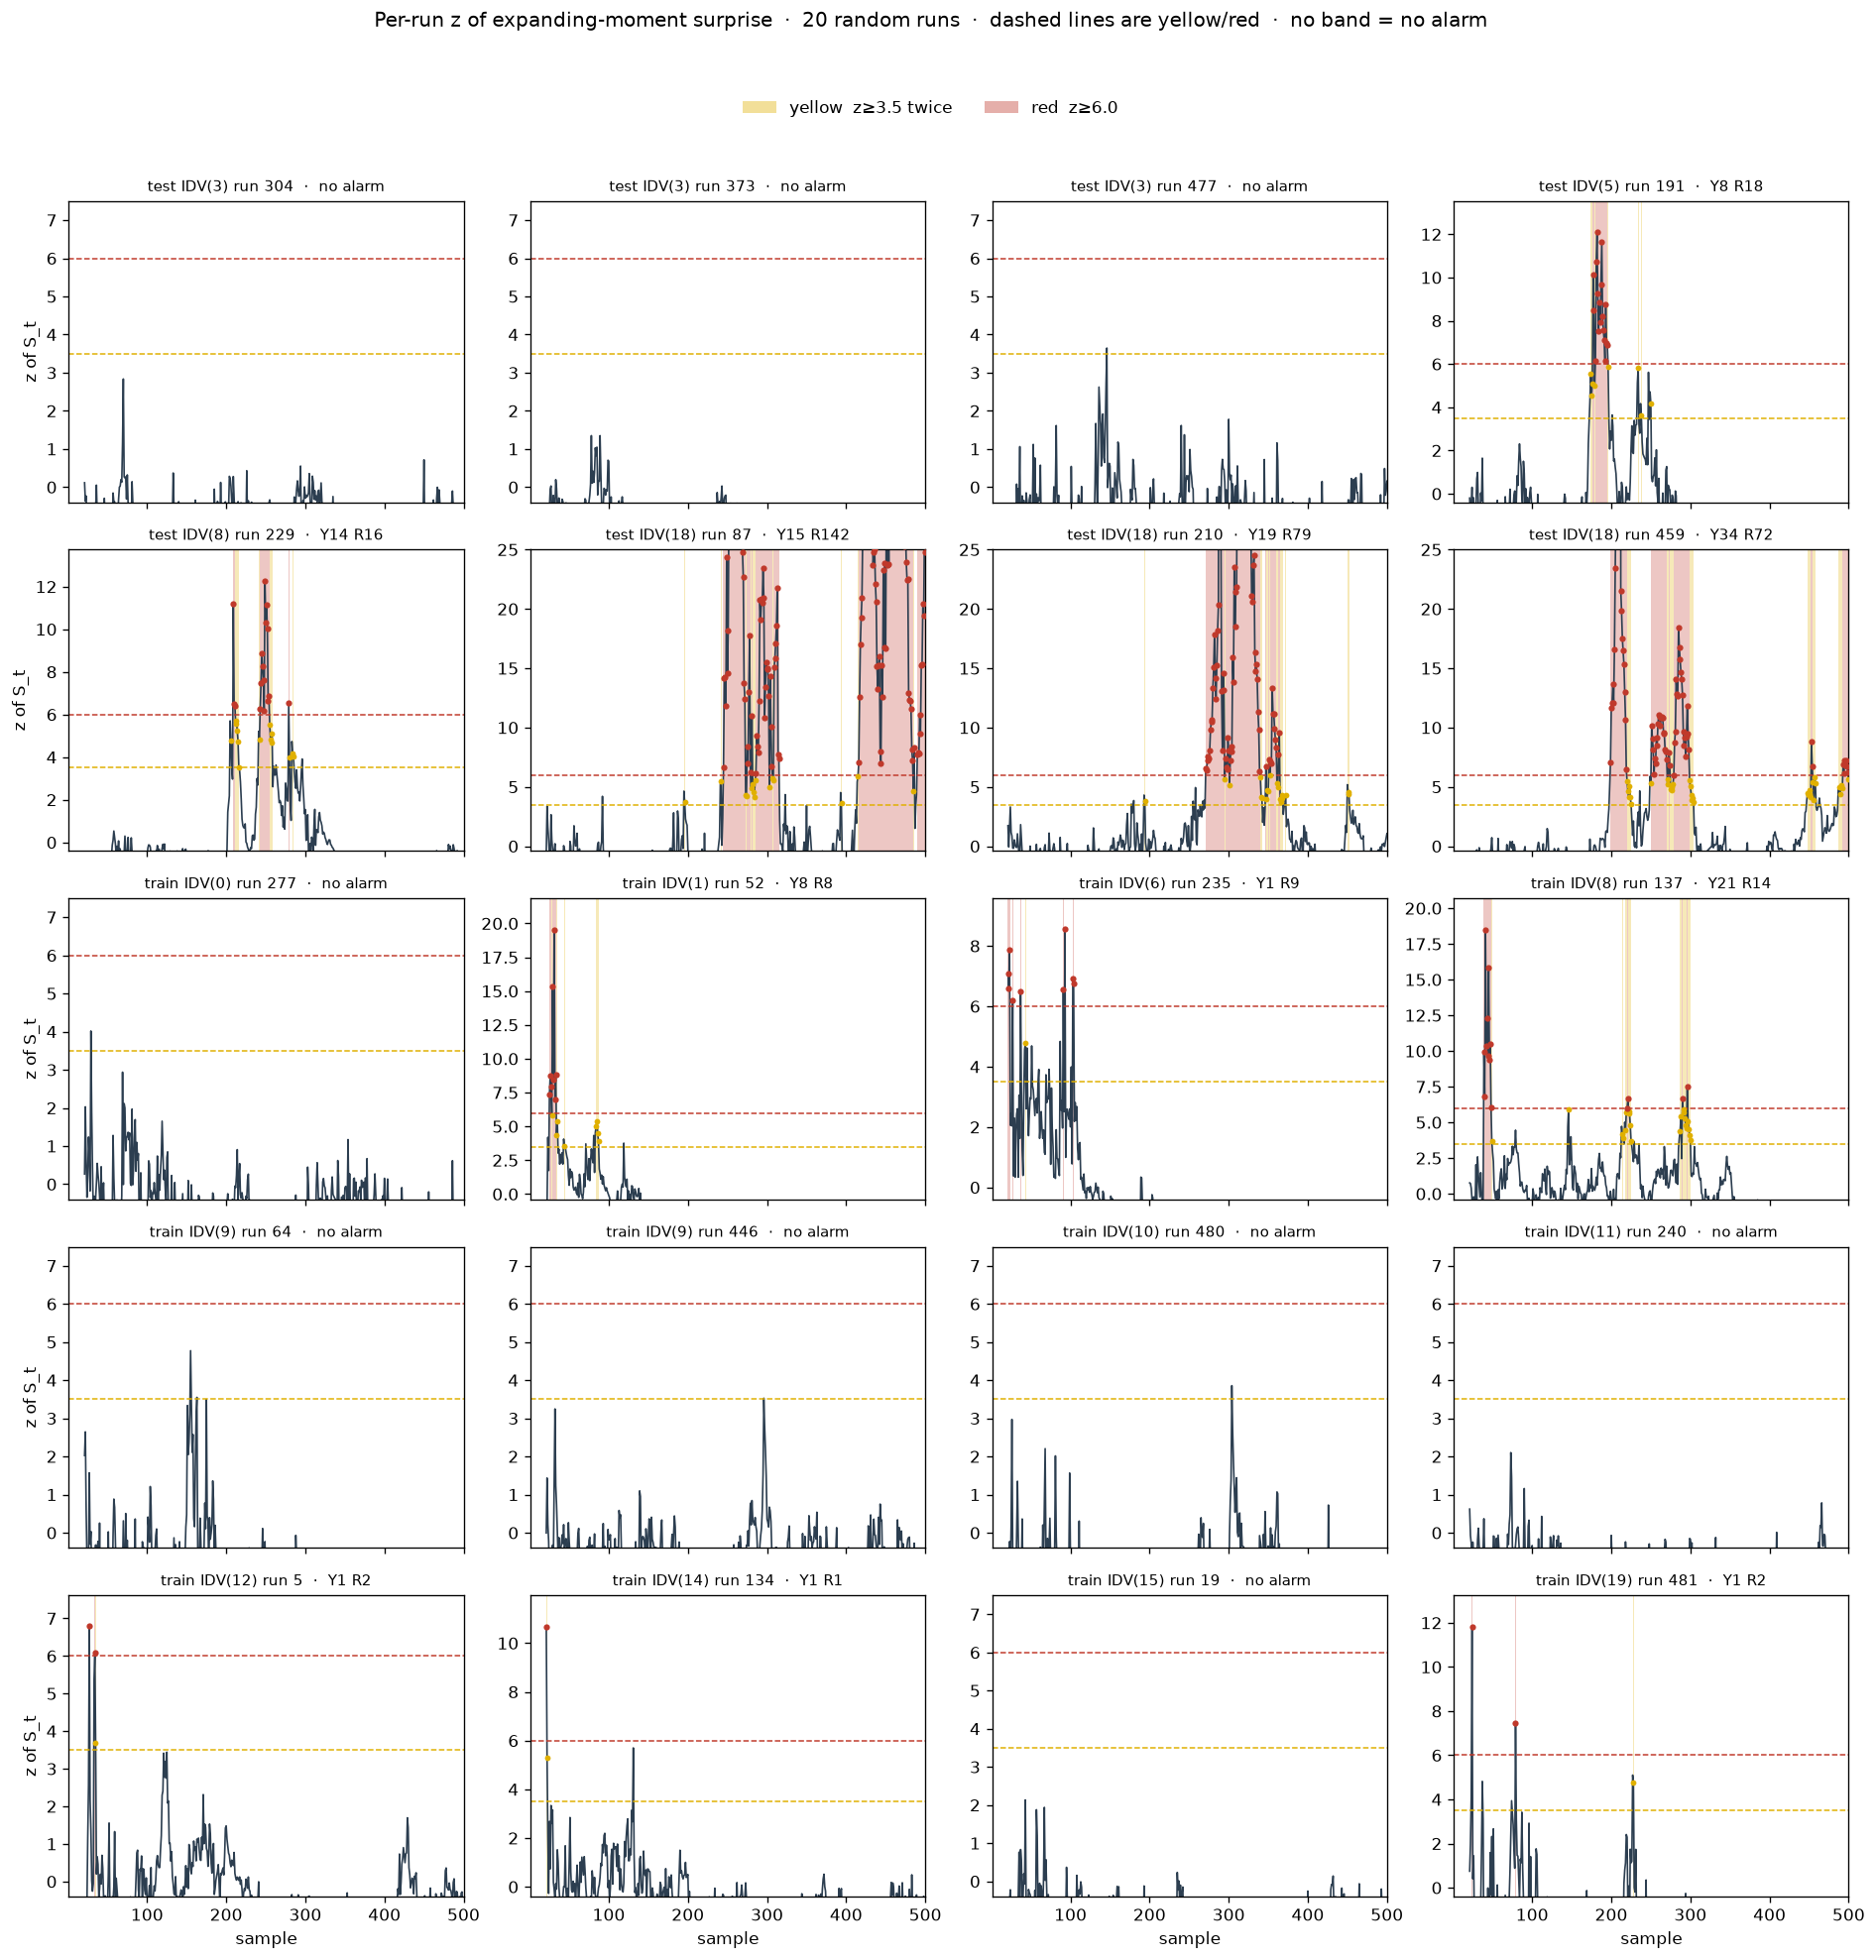

In [10]:
def shade_alarms(ax, spans: list[tuple[float, float, str]], ymax=None) -> None:
    for x0, x1, color in spans:
        ax.axvspan(x0 - 0.5, x1 + 0.5, color=color, alpha=0.28, lw=0)


def run_title(a: dict) -> str:
    n_y = int((a["level"] == 1).sum())
    n_r = int((a["level"] == 2).sum())
    extra = "no alarm" if (n_y + n_r) == 0 else f"Y{n_y} R{n_r}"
    return f"{a['source']} IDV({a['faultNumber']}) run {a['simulationRun']}  ·  {extra}"


n = len(analyzed)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.1 * nrows), sharex=True, squeeze=False)
for i, ax in enumerate(axes.ravel()):
    if i >= n:
        ax.axis("off")
        continue
    a = analyzed[i]
    s = a["samples"]
    ax.plot(s, a["z"], color="#2C3E50", lw=1.0)
    ax.axhline(YELLOW_Z, color=YELLOW, ls="--", lw=0.9)
    ax.axhline(RED_Z, color=RED, ls="--", lw=0.9)
    shade_alarms(ax, a["spans"])
    y_m = a["level"] == 1
    r_m = a["level"] == 2
    if y_m.any():
        ax.scatter(s[y_m], a["z"][y_m], s=12, c=YELLOW, zorder=3, linewidths=0)
    if r_m.any():
        ax.scatter(s[r_m], a["z"][r_m], s=14, c=RED, zorder=4, linewidths=0)
    finite_z = a["z"][np.isfinite(a["z"])]
    ymax = float(np.nanmax(finite_z)) if finite_z.size else RED_Z
    ax.set_ylim(-0.4, min(25.0, max(RED_Z + 1.5, ymax * 1.12)))
    ax.set_title(run_title(a), fontsize=9)
    ax.set_xlim(1, SAMPLE_MAX)
    if i % ncols == 0:
        ax.set_ylabel("z of S_t")
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("sample")
fig.legend(
    handles=[
        Patch(facecolor=YELLOW, alpha=0.4, label=f"yellow  z≥{YELLOW_Z} twice"),
        Patch(facecolor=RED, alpha=0.4, label=f"red  z≥{RED_Z}"),
    ],
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
fig.suptitle("Per-run z of expanding-moment surprise  ·  20 random runs  ·  dashed lines are yellow/red  ·  no band = no alarm", y=1.06, fontsize=12)
fig.tight_layout()
plt.show()


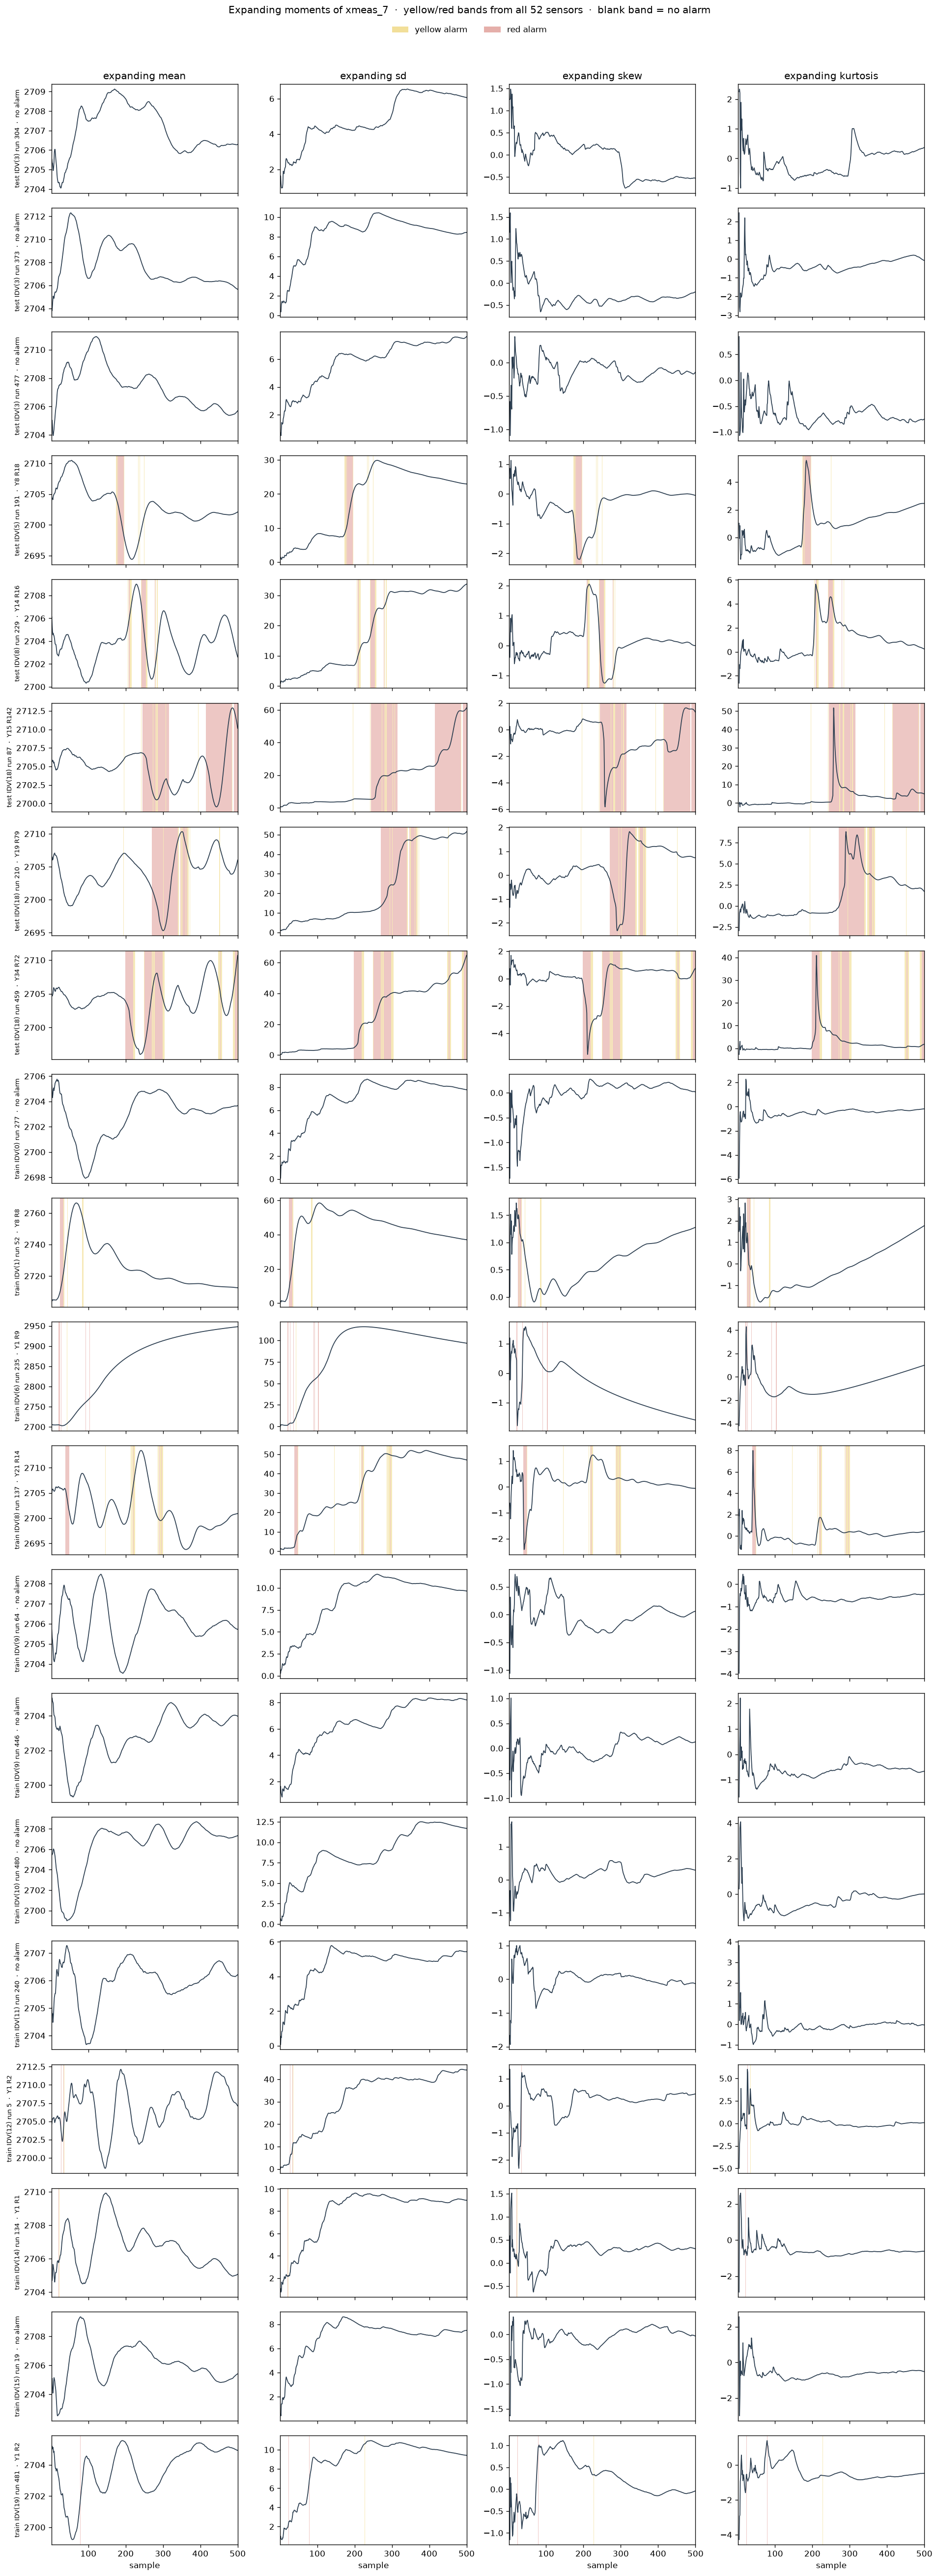

In [11]:
sensor_idx = SENSOR_COLS.index(plot_sensor)
fig, axes = plt.subplots(n, 4, figsize=(16, 2.15 * n), sharex=True, squeeze=False)
moment_keys = ("mean", "sd", "skew", "kurt")
ylabels = ("expanding mean", "expanding sd", "expanding skew", "expanding kurtosis")

for i, a in enumerate(analyzed):
    s = a["samples"]
    for j, (key, ylab) in enumerate(zip(moment_keys, ylabels)):
        ax = axes[i, j]
        ax.plot(s, a[key][:, sensor_idx], color="#2C3E50", lw=1.05)
        shade_alarms(ax, a["spans"])
        ax.set_xlim(1, SAMPLE_MAX)
        if i == 0:
            ax.set_title(ylab)
        if j == 0:
            ax.set_ylabel(run_title(a), fontsize=8)
        if i == n - 1:
            ax.set_xlabel("sample")

fig.legend(
    handles=[
        Patch(facecolor=YELLOW, alpha=0.4, label="yellow alarm"),
        Patch(facecolor=RED, alpha=0.4, label="red alarm"),
    ],
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01),
)
fig.suptitle(
    f"Expanding moments of {plot_sensor}  ·  yellow/red bands from all 52 sensors  ·  blank band = no alarm",
    y=1.015,
    fontsize=12,
)
fig.tight_layout()
plt.show()


## 5. What this is (and is not)

- **Is:** online, per-run, four-moment change detection. Thresholds come from that run's own head, so they are not fitted on a healthy catalog and do not use CSV labels.
- **Is not:** a claim about TPR/FPR. Labels in the summary table are only so we can read the 20-run draw. Hard IDVs (3, 9, 15, …) often look like the no-alarm plots — the expanding moments never jump hard enough, and that is the honest output.
- **Next:** the same `analyze_run` over all 21,000 keys. Do not keep the 15M-row table; reduce each run to its expanding-moment series + alarm list as soon as the 500 samples are in.
